In [1]:
%cd ..

/Users/stanf/Documents/Uni/MSc Thesis/doubly-robust-optim-with-Two-tower-Models


In [2]:
import pandas as pd

from notebooks.utils import load
from feature_based_propensities_for_ULTR.simulation.simulator import get_position_bias

# Plots for showing comparison between different estimators

Saved plot to notebooks/thesis_plots/propensity_estimation_frequency_based_none.pdf
Saved plot to notebooks/thesis_plots/propensity_estimation_frequency_based_MLPClassifier.pdf
Saved plot to notebooks/thesis_plots/propensity_estimation_frequency_based_cosine.pdf
Saved plot to notebooks/thesis_plots/propensity_estimation_frequency_based_KNN.pdf
Saved plot to notebooks/thesis_plots/propensity_estimation_frequency_based_MLPRegressor.pdf


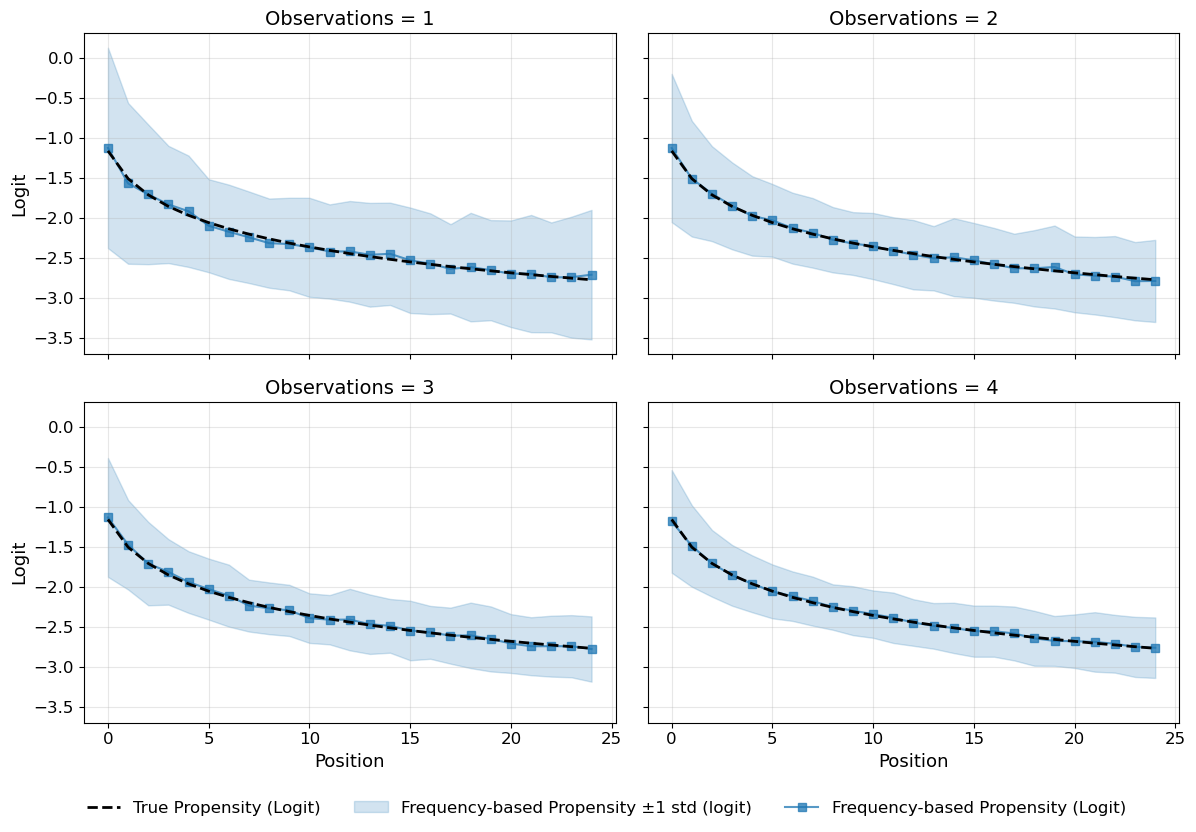

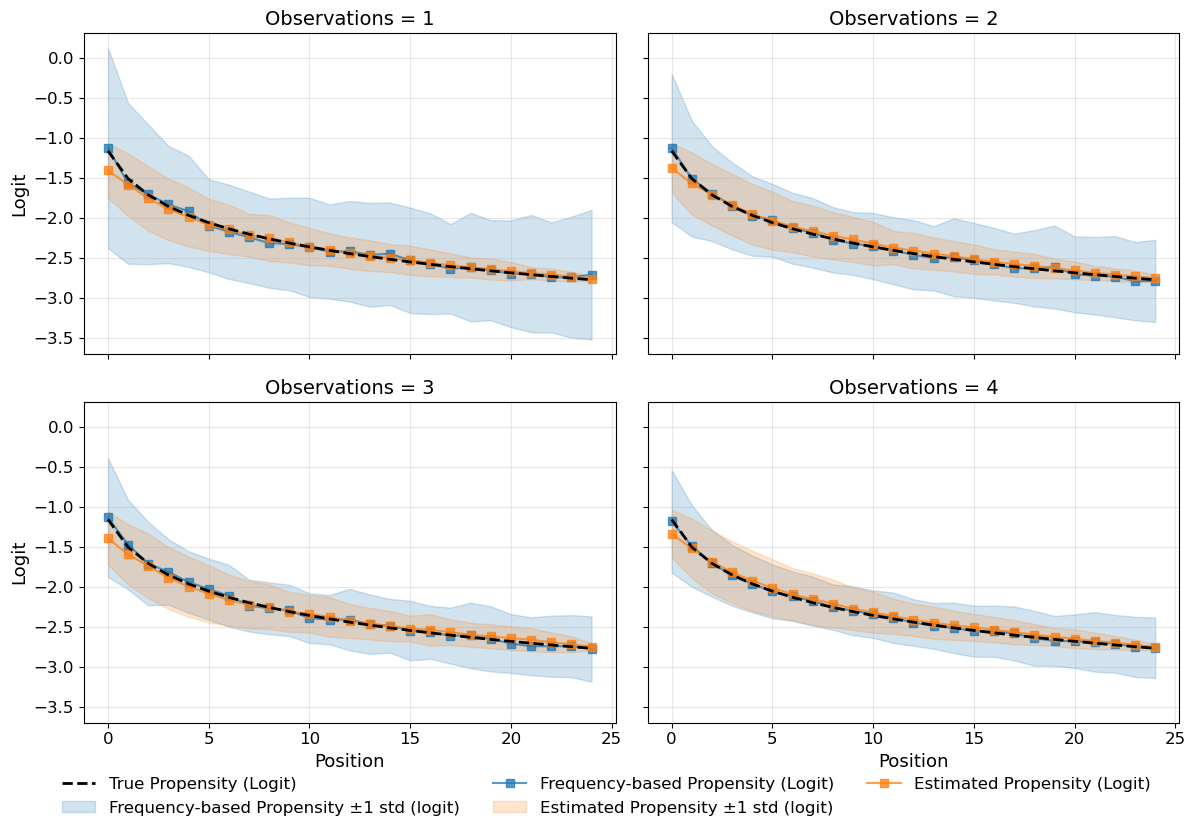

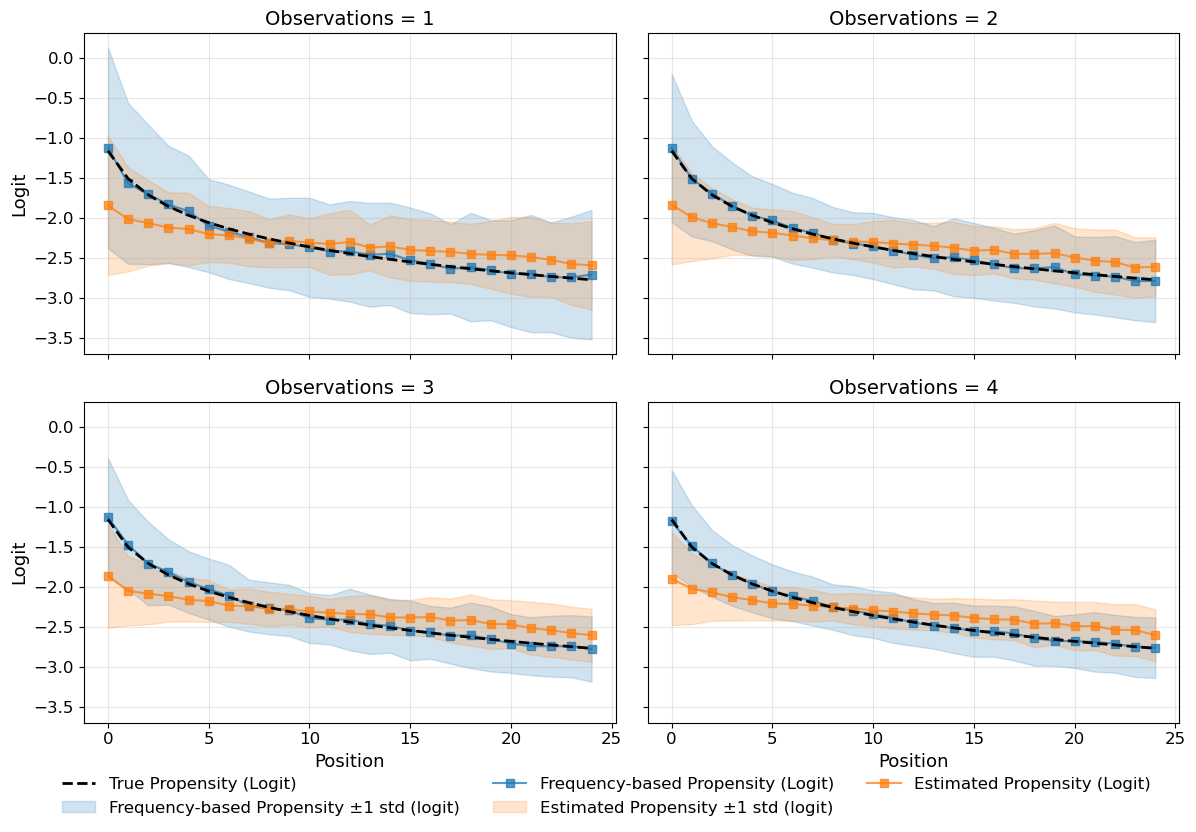

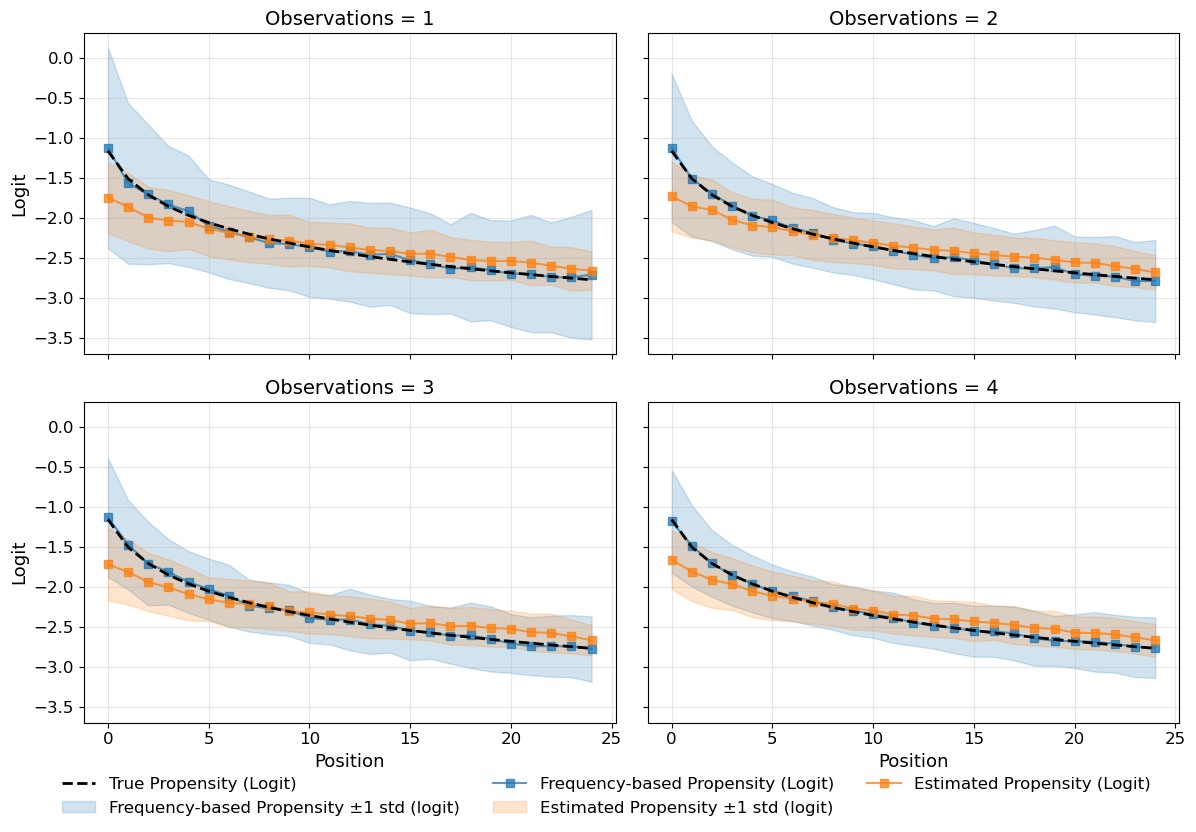

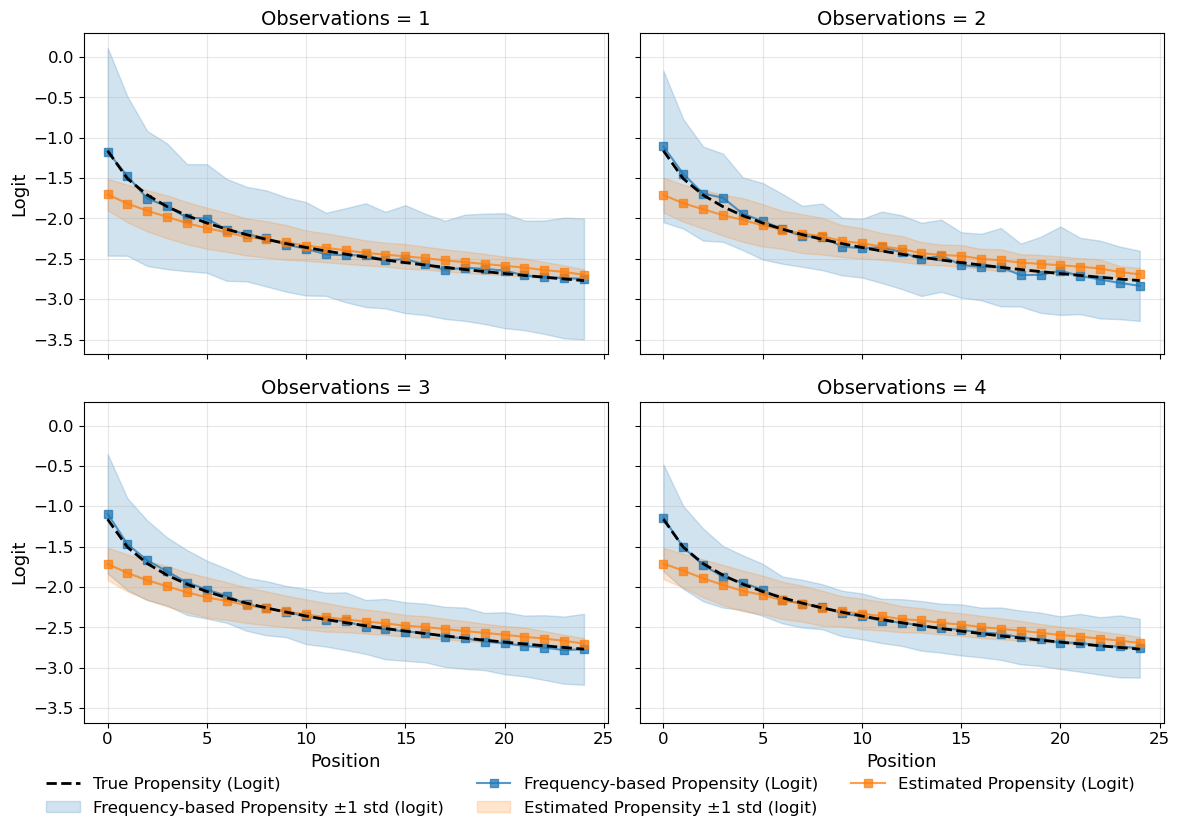

In [3]:
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_multi_panel(
    base_path: str,
    csv_path: str,
    obs_counts: list[int],
    output_path: str,
    plot_mean_pred: bool
) -> None:
    df = pd.read_csv(os.path.join(base_path, csv_path))
    positions = df["position"].to_numpy()
    effective_alpha = df["effective_alpha"].to_numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for idx, obs_count in enumerate(obs_counts):
        ax = axes[idx]
        mean_pred = df[f"pred_mean_obs{obs_count}"].to_numpy()
        std_pred = df[f"pred_std_obs{obs_count}"].to_numpy()
        mean_expected = df[f"exp_mean_obs{obs_count}"].to_numpy()
        std_expected = df[f"exp_std_obs{obs_count}"].to_numpy()
        valid = np.isfinite(mean_pred)
        pos_valid = positions[valid]

        ax.plot(
            positions,
            effective_alpha,
            label="True Propensity (Logit)",
            color="black",
            linestyle="--",
            linewidth=2.0,
            zorder=3,
        )
        ax.plot(
            pos_valid,
            mean_expected[valid],
            label="Frequency-based Propensity (Logit)",
            marker="s",
            markersize=6,
            color="tab:blue",
            alpha=0.75,
            zorder=2,
        )
        ax.fill_between(
            pos_valid,
            mean_expected[valid] - std_expected[valid],
            mean_expected[valid] + std_expected[valid],
            alpha=0.2,
            color="tab:blue",
            label="Frequency-based Propensity ±1 std (logit)",
        )
        if plot_mean_pred:
            ax.plot(
                pos_valid,
                mean_pred[valid],
                label="Estimated Propensity (Logit)",
                marker="s",
            markersize=6,
            color="tab:orange",
            alpha=0.75,
            zorder=2,
            )
            ax.fill_between(
                pos_valid,
                mean_pred[valid] - std_pred[valid],
                mean_pred[valid] + std_pred[valid],
                alpha=0.2,
                color="tab:orange",
                label="Estimated Propensity ±1 std (logit)",
            )
        ax.set_title(f"Observations = {obs_count}")
        ax.grid(True, alpha=0.3)

    for idx in range(len(obs_counts), len(axes)):
        axes[idx].set_visible(False)

    axes[0].set_ylabel("Logit")
    axes[2].set_ylabel("Logit")
    axes[2].set_xlabel("Position")
    axes[3].set_xlabel("Position")

    handles, labels = axes[0].get_legend_handles_labels()

    entries = dict(zip(labels, handles))

    true_h = entries.get("True Propensity (Logit)")
    freq_line_h = entries.get("Frequency-based Propensity (Logit)")
    est_line_h = entries.get("Estimated Propensity (Logit)")
    freq_std_h = next((h for l, h in entries.items()
                    if "Frequency-based Propensity ±1 std" in l), None)
    est_std_h = next((h for l, h in entries.items()
                    if "Estimated Propensity ±1 std" in l), None)

    # IMPORTANT: column-major ordering
    ordered_handles = [
        true_h,
        freq_std_h,
        freq_line_h,
        est_std_h,
        est_line_h,
    ]

    ordered_labels = [
        "True Propensity (Logit)",
        "Frequency-based Propensity ±1 std (logit)",
        "Frequency-based Propensity (Logit)",
        "Estimated Propensity ±1 std (logit)",
        "Estimated Propensity (Logit)",
    ]

    # Remove None entries (if plot_mean_pred=False)
    filtered = [(h, l) for h, l in zip(ordered_handles, ordered_labels) if h is not None]
    ordered_handles = [h for h, _ in filtered]
    ordered_labels = [l for _, l in filtered]

    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05),
    )
    if obs_counts:
        obs_label = f"{obs_counts[0]}–{obs_counts[-1]}"
    else:
        obs_label = "N/A"
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight", pad_inches=0.1)


obs_groups = [
    [1, 2, 3, 4],
]
obs_counts = list(range(1, 13))
per_obs_stats = {}

paths = [
    (False, "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_unsupervised_cosine_cos_t0p99_k50_obs1-12.csv", "results/compare_propensity_estimators_counts/+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_temperature=0.5,propensity_model=cosine,relevance=deep,relevance_tower=deep", "none"),
    (True, "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_propensity_mlp_classifier_clf_l4_h256_d0p3_obs1-12.csv", "results/compare_propensity_estimators_counts/+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_temperature=0.5,propensity_model=MLPclassifier,relevance=deep,relevance_tower=deep", "MLPClassifier"),
    (True, "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_unsupervised_cosine_cos_t0p993_k50_obs1-12.csv", "results/compare_propensity_estimators_counts/+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_temperature=0.5,propensity_model=cosine,relevance=deep,relevance_tower=deep", "cosine"),
    (True, "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_unsupervised_knn_knn_k2_obs1-12.csv", "results/compare_propensity_estimators_counts/+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_temperature=0.5,propensity_model=knn,relevance=deep,relevance_tower=deep", "KNN"),
    (True, "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_propensity_mlp_regression_reg_l3_h64_d0p1_obs1-12.csv", "results/compare_propensity_estimators_counts/+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_strength=1.0,policy_temperature=0.5,propensity_model=MLPregression,random_state=2023,test_clicks=50000,train_clicks=50000,val_clicks=50000", "MLPRegressor"),
]

plt.rcParams.update({
    "font.size": 13,          # base size (default is 10)   
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
for path_set in paths:
    for group in obs_groups:
        output_path = f"notebooks/thesis_plots/propensity_estimation_frequency_based_{path_set[3]}.pdf"
        plot_multi_panel(
            base_path=path_set[2],
            csv_path=path_set[1],
            obs_counts=group,
            output_path=output_path,
            plot_mean_pred=path_set[0]
        )
    print(f"Saved plot to {output_path}")

    


# Plots for showing mean and variance across observations

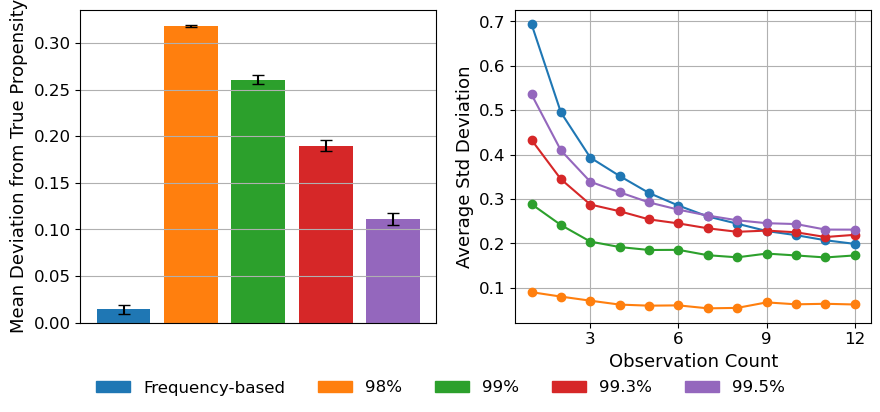

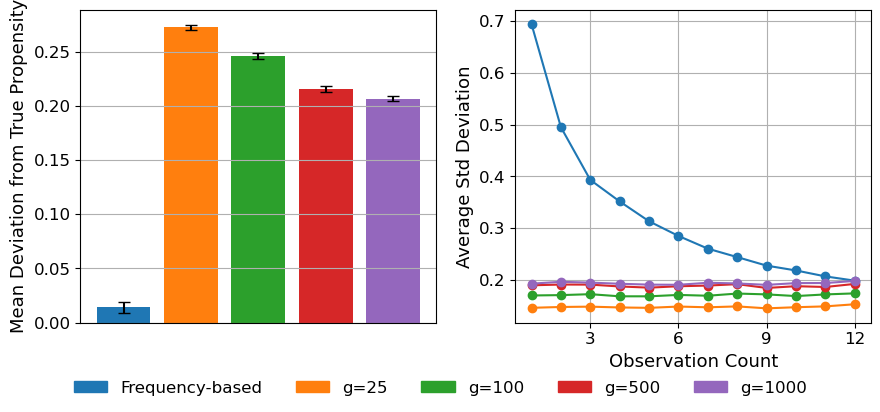

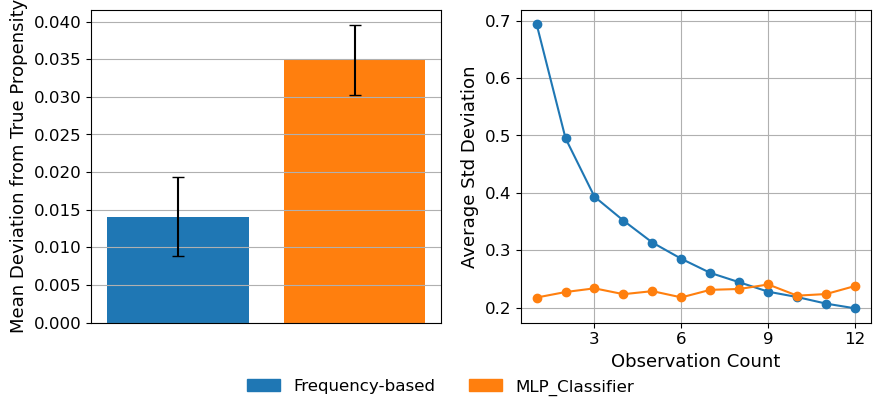

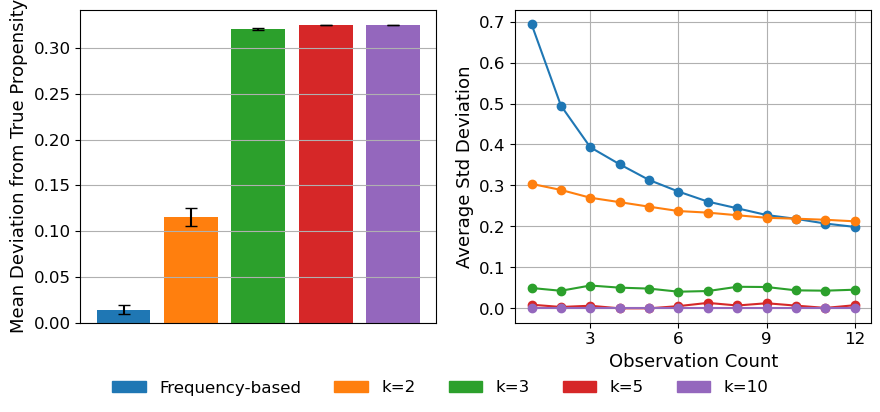

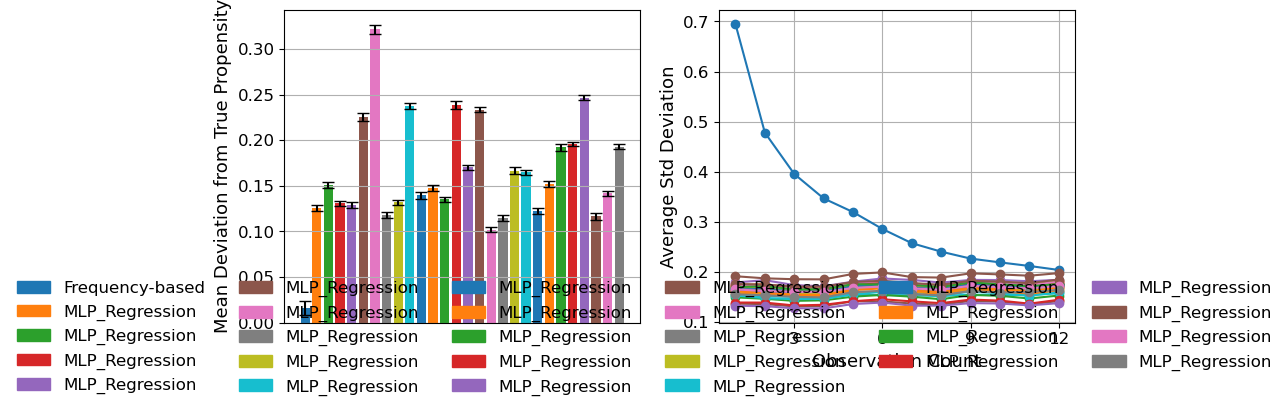

In [4]:
import os
import itertools
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================================
# 1️⃣  Summary Table Creation (Efficient + Safe)
# ==========================================================
def create_summary_table(
    base_path: str,
    file_template: str,
    obs_counts: list[int],
    param_values: dict[str, list]
) -> pd.DataFrame:

    rows = []

    # Generate all parameter combinations once
    keys = list(param_values.keys())
    values = list(param_values.values())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    # Load all CSVs once
    dataframes = {}
    for combo in combinations:
        filename = file_template.format(**combo)
        full_path = os.path.join(base_path, filename)

        if os.path.exists(full_path):
            dataframes[tuple(combo.items())] = pd.read_csv(full_path)
        else:
            print(f"Warning: File not found: {full_path}")

    # Compute metrics
    for combo in combinations:
        key = tuple(combo.items())
        if key not in dataframes:
            continue

        df = dataframes[key]
        effective = df["effective_alpha"].to_numpy()

        # Precompute dynamic method label once
        dynamic_method_name = "_".join(f"{k}{v}" for k, v in combo.items())

        for obs in obs_counts:
            for prefix, fixed_method_name in [
                ("pred", None),
                ("exp", "expected"),
            ]:

                mean_col = f"{prefix}_mean_obs{obs}"
                std_col = f"{prefix}_std_obs{obs}"

                if mean_col not in df.columns or std_col not in df.columns:
                    continue

                mean_vals = df[mean_col].to_numpy()
                std_vals = df[std_col].to_numpy()
                valid = np.isfinite(mean_vals)

                method_name = (
                    dynamic_method_name
                    if fixed_method_name is None
                    else fixed_method_name
                )

                rows.append({
                    "obs_count": obs,
                    "avg_std": np.mean(std_vals[valid]),
                    "mean_abs_deviation_from_true":
                        np.mean(np.abs(mean_vals[valid] - effective[valid])),
                    "method": method_name,
                    **combo,
                })

    return pd.DataFrame(rows)


# ==========================================================
# 2️⃣  Generic Plotting Function (Reusable)
# ==========================================================
import matplotlib.patches as mpatches

def plot_summary(
    summary_df: pd.DataFrame,
    output_path: str,
    label_formatter,
    left_ylabel: str,
    right_ylabel: str,
    method_sort_key,
    left_title: str | None = None,
    right_title: str | None = None,
):

    summary_df = summary_df.drop_duplicates(subset=["obs_count", "method"])

    pivot_dev = summary_df.pivot(
        index="obs_count",
        columns="method",
        values="mean_abs_deviation_from_true"
    )

    pivot_std = summary_df.pivot(
        index="obs_count",
        columns="method",
        values="avg_std"
    )

    methods = pivot_dev.columns.tolist()

    if method_sort_key is not None:
        methods = sorted(methods, key=method_sort_key)

    # Reorder pivots to match sorted order
    pivot_dev = pivot_dev[methods]
    pivot_std = pivot_std[methods]
    obs_counts = pivot_dev.index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    # Use consistent color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # =====================================================
    # --- Left Plot: Averaged Bar Plot ---
    # =====================================================
    mean_over_obs = pivot_dev.mean(axis=0)
    std_over_obs = pivot_dev.std(axis=0)

    x = np.arange(len(methods))

    for i, method in enumerate(methods):
        axes[0].bar(
            x[i],
            mean_over_obs[method],
            yerr=std_over_obs[method],
            capsize=4,
            color=colors[i % len(colors)]
        )

    axes[0].set_xticks([])  # no x-axis labels
    axes[0].set_ylabel(left_ylabel)
    if left_title:
        axes[0].set_title(left_title)
    axes[0].grid(True, axis="y")

    # =====================================================
    # --- Right Plot: Line Plot (Same Colors) ---
    # =====================================================
    lines = []
    for i, method in enumerate(methods):
        line, = axes[1].plot(
            obs_counts,
            pivot_std[method].values,
            marker='o',
            color=colors[i % len(colors)],
            label=label_formatter(method)
        )
        lines.append(line)

    axes[1].set_xlabel("Observation Count")
    axes[1].set_ylabel(right_ylabel)

    xticks = [x for x in [3, 6, 9, 12] if x in obs_counts]
    axes[1].set_xticks(xticks)

    if right_title:
        axes[1].set_title(right_title)

    axes[1].grid(True)

    # =====================================================
    # --- Shared Legend: Use Colored Patches for Bars ---
    # =====================================================
    legend_handles = [
        mpatches.Patch(color=colors[i % len(colors)], label=label_formatter(method))
        for i, method in enumerate(methods)
    ]

    fig.legend(
        handles=legend_handles,
        labels=[h.get_label() for h in legend_handles],
        loc='lower center',
        ncol=min(len(methods), 6),
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()


# ==========================================================
# 3️⃣  COSINE EXPERIMENT
# ==========================================================
cosine_base_path = (
    "results/"
    "compare_propensity_estimators_counts/"
    "+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,"
    "logging_policy_ranker=deep,policy_temperature=0.5,"
    "propensity_model=cosine,relevance=deep,relevance_tower=deep"
)

cosine_template = (
    "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_"
    "unsupervised_cosine_cos_t0p{p}_k50_obs1-12.csv"
)

cosine_summary = create_summary_table(
    base_path=cosine_base_path,
    file_template=cosine_template,
    param_values={"p": [98, 99, 993, 995]},
    obs_counts=list(range(1, 13)),
)

def cosine_label(method_name):
    if method_name.lower() == "expected":
        return "Frequency-based"

    match = re.search(r"\d+$", method_name)
    if not match:
        return method_name

    value = int(match.group(0))

    # If value has 3 digits, interpret as one decimal place
    if value >= 100:
        return f"{value / 10:.1f}%"
    else:
        return f"{value}%"

plot_summary(
    summary_df=cosine_summary,
    output_path="notebooks/thesis_plots/propensity_estimation_Cosine_Sim.pdf",
    label_formatter=cosine_label,
    method_sort_key=None,
    left_ylabel="Mean Deviation from True Propensity",
    right_ylabel="Average Std Deviation",
)



# ==========================================================
# 4 KMEANS CLUSTERING EXPERIMENT
# ==========================================================


kmeans_base_path = (
    "results/"
    "compare_propensity_estimators_counts/"
    "+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,"
    "logging_policy_ranker=deep,policy_temperature=0.5,"
    "propensity_model=kmeans,relevance=deep,relevance_tower=deep"
)

kmeans_template = (
    "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_unsupervised_kmeans_kmeans_g{g_size}_min1_it3_obs1-12.csv"
)

kmeans_summary = create_summary_table(
    base_path=kmeans_base_path,
    file_template=kmeans_template,
    param_values={"g_size": [25, 100, 500, 1000]},
    obs_counts=list(range(1, 13)),
)


def kmeans_label(method_name):
    if method_name.lower() == "expected":
        return "Frequency-based"

    g_match = re.search(r"g_size(\d+)", method_name)

    g_val = g_match.group(1) if g_match else "?"

    return f"g={g_val}"

def kmeans_sort_key(method_name):
    if method_name.lower() == "expected":
        return -1  # ensures Frequency-based appears first
    match = re.search(r"g_size(\d+)", method_name)
    return int(match.group(1)) if match else 999999

plot_summary(
    summary_df=kmeans_summary,
    output_path="notebooks/thesis_plots/propensity_estimation_KMeans.pdf",
    label_formatter=kmeans_label,
    method_sort_key=kmeans_sort_key,
    left_ylabel="Mean Deviation from True Propensity",
    right_ylabel="Average Std Deviation",
)

# ==========================================================
# 5 MLP CLASSIFIER EXPERIMENT
# ==========================================================
mlp_classifier_base_path = (
    "results/"
    "compare_propensity_estimators_counts/"
    "+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_temperature=0.5,propensity_model=MLPclassifier,relevance=deep,relevance_tower=deep"
)

mlp_classifier_template = (
    "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_propensity_mlp_classifier_clf_l{l}_h{h}_d0p{p}_obs1-12.csv"
)

mlp_classifier_summary = create_summary_table(
    base_path=mlp_classifier_base_path,
    file_template=mlp_classifier_template,
    param_values={"l": [4], "h": [256], "p": [3]},
    obs_counts=list(range(1, 13)),
)


def mlp_classifier_label(method_name):
    if method_name.lower() == "expected":
        return "Frequency-based"
    return "MLP_Classifier"


plot_summary(
    summary_df=mlp_classifier_summary,
    output_path="notebooks/thesis_plots/propensity_estimation_MLP_Classifier.pdf",
    label_formatter=mlp_classifier_label,
    method_sort_key=None,
    left_ylabel="Mean Deviation from True Propensity",
    right_ylabel="Average Std Deviation",
)



# KNN Clustering Experiment

knn_base_path = (
    "results/"
    "compare_propensity_estimators_counts/"
    "+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,"
    "logging_policy_ranker=deep,policy_temperature=0.5,"
    "propensity_model=knn,relevance=deep,relevance_tower=deep"
)

knn_template = (
    "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_unsupervised_knn_knn_k{knn_k}_obs1-12.csv"
)

knn_summary = create_summary_table(
    base_path=knn_base_path,
    file_template=knn_template,
    param_values={"knn_k": [2, 3, 5, 10]},
    obs_counts=list(range(1, 13)),
)


def knn_label(method_name):
    if method_name.lower() == "expected":
        return "Frequency-based"
    match = re.search(r"knn_k(\d+)", method_name)
    return f"k={match.group(1)}" if match else method_name


def knn_sort_key(method_name):
    if method_name.lower() == "expected":
        return -1  # ensures Frequency-based appears first
    match = re.search(r"knn_k(\d+)", method_name)
    return int(match.group(1)) if match else 999999

plot_summary(
    summary_df=knn_summary,
    output_path="notebooks/thesis_plots/propensity_estimation_KNN.pdf",
    label_formatter=knn_label,
    method_sort_key=knn_sort_key,
    left_ylabel="Mean Deviation from True Propensity",
    right_ylabel="Average Std Deviation",
)

# ==========================================================
# 6. Regression MLP
# ==========================================================

mlp_regression_base_path = (
    "results/"
    "compare_propensity_estimators_counts/"
    "+launcher=slurmcpu,data=mslr30k,experiment=compare_propensity_estimators_counts,logging_policy_ranker=deep,policy_strength=1.0,policy_temperature=0.5,propensity_model=MLPregression,random_state=2023,test_clicks=50000,train_clicks=50000,val_clicks=50000"
)


mlp_regression_template = (
    "compare_propensity_tc50000_te50000_ps1p0_pt0p5_bs1p0_propensity_mlp_regression_reg_l{l}_h{h}_d0p{p}_obs1-12.csv"
)

mlp_regression_summary = create_summary_table(
    base_path=mlp_regression_base_path,
    file_template=mlp_regression_template,
    param_values={"l": [2,3,4], "h": [64,128,256], "p": [1,2,3]},
    obs_counts=list(range(1, 13)),
)


# 3, 64, 1

def mlp_label(method_name):
    if method_name.lower() == "expected":
        return "Frequency-based"
    return "MLP_Regression"


plot_summary(
    summary_df=mlp_regression_summary,
    output_path="notebooks/thesis_plots/propensity_estimation_MLP_Regression.pdf",
    label_formatter=mlp_label,
    method_sort_key=None,
    left_ylabel="Mean Deviation from True Propensity",
    right_ylabel="Average Std Deviation",
)






In [5]:
# take the mean over the mean_abs_deviation_from_true for each unqique method

mlp_regression_summary[mlp_regression_summary.method != "expected"].groupby("method")["mean_abs_deviation_from_true"].mean().sort_values()

method
l3_h64_p1     0.101891
l3_h64_p2     0.114614
l4_h64_p1     0.116559
l2_h64_p1     0.118107
l4_h128_p2    0.122432
l2_h128_p1    0.125451
l2_h256_p1    0.129014
l2_h128_p3    0.130673
l2_h64_p2     0.131900
l3_h128_p3    0.135453
l3_h128_p1    0.139694
l4_h64_p2     0.141929
l3_h128_p2    0.147613
l2_h128_p2    0.151062
l4_h128_p3    0.151737
l4_h128_p1    0.165044
l3_h64_p3     0.166797
l3_h256_p2    0.170210
l4_h256_p1    0.192221
l4_h64_p3     0.192945
l4_h256_p2    0.196092
l2_h256_p2    0.225637
l3_h256_p3    0.233692
l2_h64_p3     0.237758
l3_h256_p1    0.238593
l4_h256_p3    0.246945
l2_h256_p3    0.321965
Name: mean_abs_deviation_from_true, dtype: float64

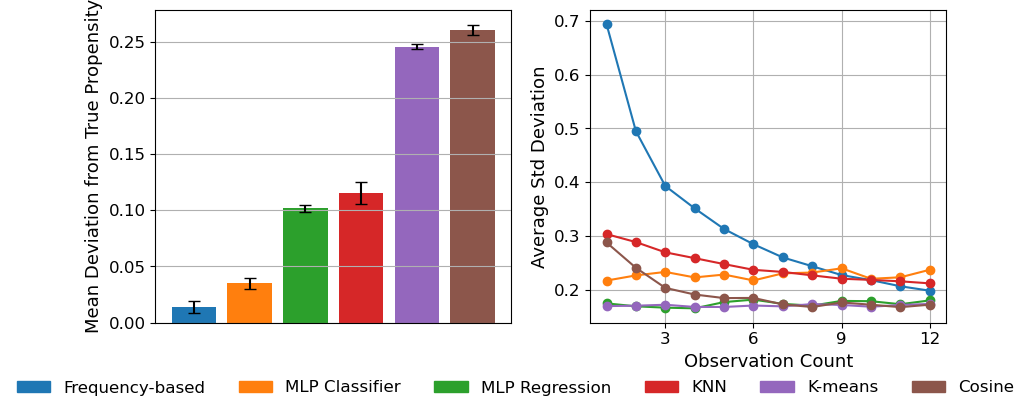

In [6]:
# --- K-means g=100 ---
kmeans_g100 = kmeans_summary[
    kmeans_summary["method"].str.contains("g_size100", na=False)
].copy()
kmeans_g100["method"] = "K-means"

# --- KNN ---
knn_2 = knn_summary[
    knn_summary["method"].str.contains("knn_k2", na=False)
].copy()
knn_2["method"] = "KNN"

# --- MLP ---
mlp_4_256_3 = mlp_classifier_summary[
    mlp_classifier_summary["method"].str.contains("l4_h256_p3", na=False)
].copy()
mlp_4_256_3["method"] = "MLP Classifier"

# --Cosine ---
cosine_99 = cosine_summary[
    cosine_summary["method"].str.contains("p99", na=False)
].copy()
cosine_99["method"] = "Cosine"

# --Frequency-based --
frequency_based = mlp_classifier_summary[
    mlp_classifier_summary["method"].str.contains("expected", na=False)
].copy()
frequency_based["method"] = "Frequency-based"

# --- MLP Regression ---
mlp_reg = mlp_regression_summary[
    mlp_regression_summary["method"].str.contains("l3_h64_p1", na=False)
].copy()
mlp_reg["method"] = "MLP Regression"

# ----------------------------------------------------------
# 2️⃣ Combine
# ----------------------------------------------------------

combined_summary = pd.concat(
    [mlp_4_256_3, kmeans_g100, knn_2, cosine_99, frequency_based, mlp_reg],
    ignore_index=True
)

# Remove duplicates if any
combined_summary = combined_summary.drop_duplicates(
    subset=["obs_count", "method"]
)

# ----------------------------------------------------------
# 3️⃣ Sorting order
# ----------------------------------------------------------

def final_sort_key(method_name):
    order = {
        "Frequency-based": 0,
        "MLP Classifier": 1,
        "MLP Regression": 2,
        "KNN": 3,
        "K-means": 4,
        "Cosine": 5,
    }
    return order.get(method_name, 999)

# ----------------------------------------------------------
# 4️⃣ Plot
# ----------------------------------------------------------

plot_summary(
    summary_df=combined_summary,
    output_path="notebooks/thesis_plots/propensity_estimation_FINAL_COMPARISON.pdf",
    label_formatter=lambda x: x,
    method_sort_key=final_sort_key,
    left_ylabel="Mean Deviation from True Propensity",
    right_ylabel="Average Std Deviation",
    left_title=None,
    right_title=None,
)